In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.shape

(400, 5)

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.drop(['User ID'],axis=1,inplace=True)

In [6]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [7]:
df.Purchased.value_counts()

,count
Purchased,
0,257
1,143


In [8]:
df.Gender.value_counts()

,count
Gender,
Female,204
Male,196


In [9]:
df.dtypes

,0
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


In [10]:
df.isnull().sum()

,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [11]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

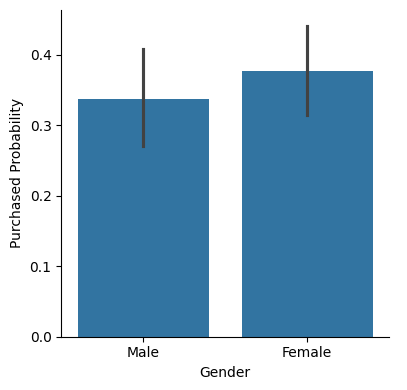

In [12]:
g=sns.catplot(x="Gender",y="Purchased",data=df,kind="bar",height=4)
g.set_ylabels("Purchased Probability")
plt.show

Purchased         0         1
Gender                       
Female     0.622549  0.377451
Male       0.663265  0.336735


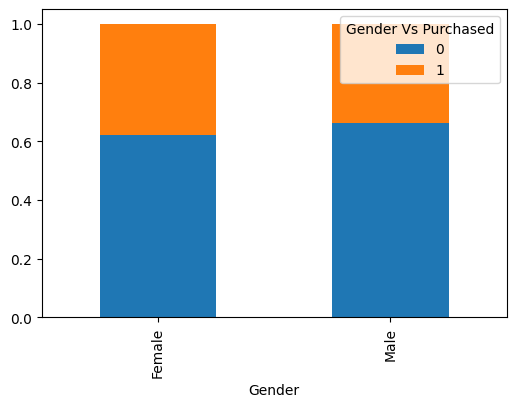

In [13]:
m2=pd.crosstab(df.Gender,df.Purchased,normalize='index')
print(m2)
m2.plot.bar(figsize=(6,4),stacked=True)
plt.legend(title='Gender Vs Purchased',loc='upper right')
plt.show()

(3, 3)


<Axes: >

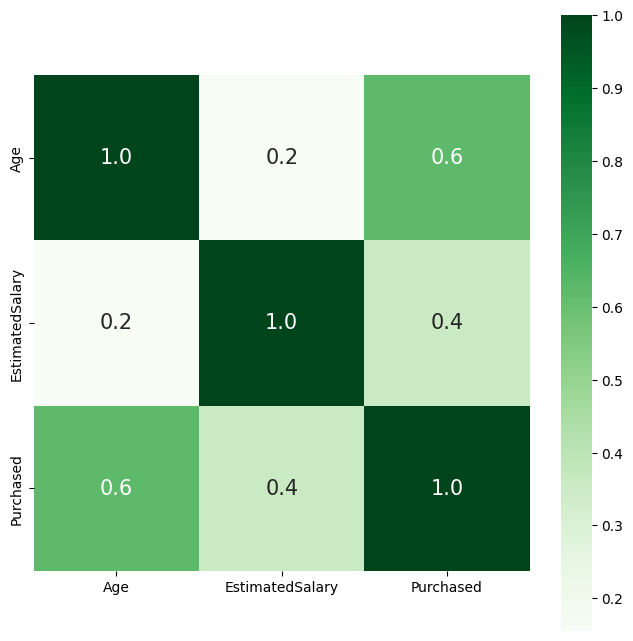

In [14]:
corr = df.corr(numeric_only=True)
print(corr.shape)
plt.figure(figsize=(8,8))
sns.heatmap(corr, cbar=True, square= True, fmt='.1f', annot=True, annot_kws={'size':15}, cmap='Greens')


In [15]:
X=df.drop(['Gender','Purchased'],axis=1)
Y=df['Purchased']
X.head()

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression
basemodel=LogisticRegression()
basemodel.fit(X_train,Y_train)
print("Training  Accuracy:",basemodel.score(X_train,Y_train)*100)


Training  Accuracy: 83.75


In [18]:
y_predict=basemodel.predict(X_test)
print("Testing accuracy:",basemodel.score(X_test,Y_test)*100)

Testing accuracy: 88.75


In [19]:
from sklearn .preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [20]:
X=df[['Age','EstimatedSalary']]
X_scaled=scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test=train_test_split(X_scaled, Y, test_size=0.2,random_state=42)
print("Training and Testing split was successful.")

Training and Testing split was successful.


In [21]:
model=LogisticRegression()
model.fit(X_train,Y_train)
Y_predict=model.predict(X_test)
print("Training accuracy:",model.score(X_train,Y_train)*100)
print("Testing accuracy:",model.score(X_test,Y_test)*100)


Training accuracy: 80.9375
Testing accuracy: 87.5


In [22]:
from sklearn.metrics import accuracy_score
Acc=accuracy_score(Y_test,Y_predict)
print(Acc)

0.875


In [23]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_predict)
print(cm)

[[51  1]
 [ 9 19]]


In [24]:
from sklearn.metrics import precision_recall_fscore_support
prf=precision_recall_fscore_support(Y_test,Y_predict)
print('precision:',prf[0])
print('Recall:',prf[1])
print('fscore:',prf[2])
print('support:',prf[3])


precision: [0.85 0.95]
Recall: [0.98076923 0.67857143]
fscore: [0.91071429 0.79166667]
support: [52 28]


In [25]:
from sklearn.metrics import classification_report
cr=classification_report(Y_test,Y_predict)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.98      0.91        52
           1       0.95      0.68      0.79        28

    accuracy                           0.88        80
   macro avg       0.90      0.83      0.85        80
weighted avg       0.89      0.88      0.87        80

